# Example: tidal analysis and prediction

This example demonstrates how to perform tidal analysis and prediction using this package in Julia. We will use historical tide gauge data to analyze the tidal patterns and compute the practical surge.

In [1]:
# Import necessary packages (Julia code snippet)
using Pkg
Pkg.activate(".")
using hatyan_small
using Plots
using Dates

  Activating project at `~/deepblack/src/AIHydroPoints.jl_claude/hatyan_small`


In [12]:
# Load observed water levels from a DONAR file
obs = read_donar_timeseries("test_data/VLISSGN_obs19.txt")
@show obs
# select a subset of the data for analysis
start_time = DateTime("1990-01-01T00:00:00")
end_time = DateTime("1990-12-31T23:59:59")
obs1990 = select_timespan(obs, start_time, end_time)
@show obs1990
# select a subset for the February 1990 storm event
start_time_feb1990 = DateTime("1990-02-22T00:00:00")
end_time_feb1990 = DateTime("1990-03-02T23:59:59")
obs_feb1990 = select_timespan(obs, start_time_feb1990, end_time_feb1990)
@show obs_feb1990

obs = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 166560
   Data shape: (1, 166560)
   Times: 1976-01-01T00:00:00 to 1994-12-31T23:00:00
   Locations: Vlissingen

obs1990 = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 8760
   Data shape: (1, 8760)
   Times: 1990-01-01T00:00:00 to 1990-12-31T23:00:00
   Locations: Vlissingen

obs_feb1990 = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 216
   Data shape: (1, 216)
   Times: 1990-02-22T00:00:00 to 1990-03-02T23:00:00
   Locations: Vlissingen



TimeSeries: WATHTE (NAP) from VLISSGN, with 1 locations, from 1990-02-22T00:00:00 until 1990-03-02T23:00:00.


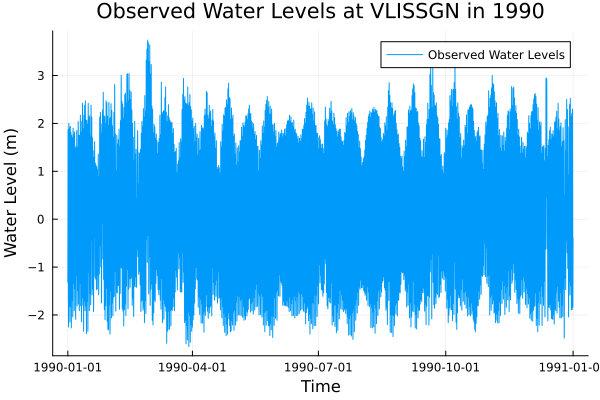

In [4]:
# Plot the observed water levels for 1990
# Note that the value array is 2D with dimensions (N_locations, N_times), so we need to index the first dimension to get a 1D array for plotting
plot(get_times(obs1990), get_values(obs1990)[1,:], label="Observed Water Levels", 
    xlabel="Time", ylabel="Water Level (m)", title="Observed Water Levels at VLISSGN in 1990", legend=:topright)
# times=get_times(obs1990)
# values=get_values(obs1990)[1,:]
# @show size(times),times
# @show size(values),values
# plot(times, values, label="Observed Water Levels", 
#     xlabel="Time", ylabel="Water Level (m)", title="Observed Water Levels at VLISSGN in 1990", legend=:topright)

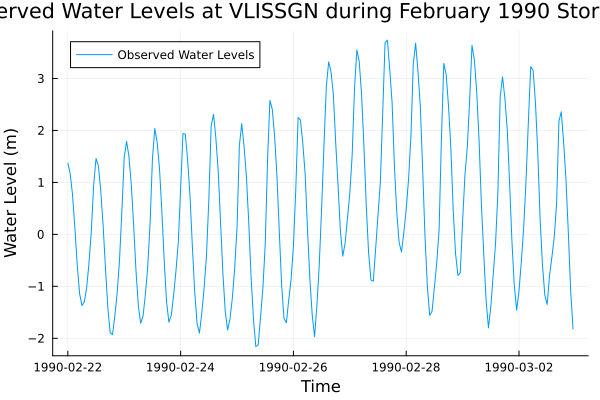

In [13]:
# Plot February 1990 storm event
plot(get_times(obs_feb1990), get_values(obs_feb1990)[1,:], label="Observed Water Levels", 
    xlabel="Time", ylabel="Water Level (m)", title="Observed Water Levels at VLISSGN during February 1990 Storm Event", 
    legend=:topleft)

In [15]:
# Choose a constituent set appropriate for the record length
# "year" = 95 constituents (A0 + 94), requires ~1 year of data
const_list = constituent_list("year")

# Fit the constituents by least-squares harmonic analysis
tc = analysis(obs, const_list)
# => TidalConstituents: water level from VLISSGN | analysis(schureman)

@show tc

tc = TidalConstituents:
   Quantity:         WATHTE (NAP)
   Source:           VLISSGN | analysis(schureman)
   Locations:        Vlissingen
   N locations:      1
   N constituents:   95
   Constituents:     A0, SA, SM, Q1, O1, M1C, P1, S1, K1, 3MKS2, 3MS2, OQ2, MNS2, 2ML2S2, NLK2, MU2, N2, NU2, MSK2, MPS2, M2, MSP2, MKS2, LABDA2, 2MN2, T2, S2, K2, MSN2, 2SM2, SKM2, NO3, 2MK3, 2MP3, SO3, MK3, SK3, 4MS4, 2MNS4, 3MS4, MN4, 2MLS4, 2MSK4, M4, 3MN4, MS4, MK4, 2MSN4, S4, MNO5, 3MK5, 2MP5, 3MO5, MSK5, 3KM5, 3MNS6, 2NM6, 4MS6, 2MN6, 2MNU6, 3MSK6, M6, MSN6, MKNU6, 2MS6, 2MK6, 3MSN6, 2SM6, MSK6, 2MNO7, M7, 2MSO7, 2(MN)8, 3MN8, M8, 2MSN8, 2MNK8, 3MS8, 3MK8, 2(MS)8, 2MSK8, 3MNK9, 4MK9, 3MSK9, 4MN10, M10, 3MSN10, 4MS10, 2(MS)N10, 3M2S10, 4MSK11, M12, 4MSN12, 5MS12, 4M2S12
   Data shape:       (1, 95) [locations × constituents]



TidalConstituents: WATHTE (NAP) from VLISSGN | analysis(schureman), 1 locations, 95 constituents.


In [16]:
# Inspect results
A   = get_amplitudes(tc)           # Matrix{Float32} [locations × constituents]
phi = get_phases(tc)               # phases in degrees
names = get_constituent_names(tc)  # ["A0", "SA", "SM", "Q1", ...]

i_M2 = findfirst(==("M2"), names)
println("M2 amplitude : ", A[1, i_M2], " m")
println("M2 phase     : ", phi[1, i_M2], " °")
println("Source       : ", get_source(tc))
# => Source: VLISSGN | analysis(schureman)


M2 amplitude : 1.7408864 m
M2 phase     : 60.08594 °
Source       : VLISSGN | analysis(schureman)


In [18]:
# Predict water levels using the fitted constituents for 1990
pred1990 = prediction(tc, get_times(obs1990))
# => TimeSeries: water level from VLISSGN | predict(schureman)

TimeSeries: WATHTE (NAP) from VLISSGN | analysis(schureman) | prediction, with 1 locations, from 1990-01-01T00:00:00 until 1990-12-31T23:00:00.


In [21]:
# Compute the practical surge by subtracting the predicted tidal signal from the observed water levels
surge1990 = TimeSeries(get_values(obs1990) .- get_values(pred1990),get_times(obs1990), get_names(obs1990), 
    get_longitudes(obs1990), get_latitudes(obs1990), "surge", get_source(obs1990))

TimeSeries: surge from VLISSGN, with 1 locations, from 1990-01-01T00:00:00 until 1990-12-31T23:00:00.


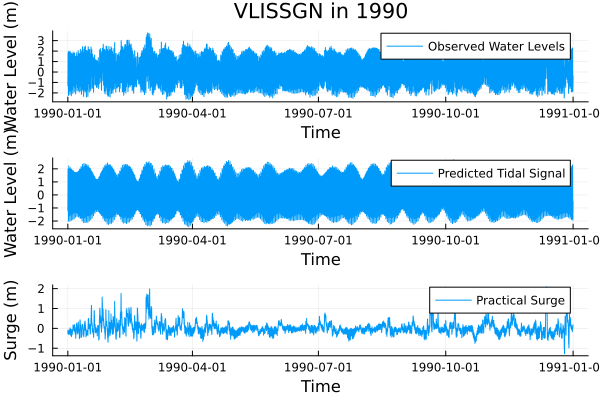

In [25]:
# Plot the observed water levels, preded tidal signal, and practical surge for 1990
p1=plot(get_times(obs1990), get_values(obs1990)[1,:], label="Observed Water Levels", 
    xlabel="Time", ylabel="Water Level (m)", title="VLISSGN in 1990", legend=:topright)
p2=plot(get_times(pred1990), get_values(pred1990)[1,:], label="Predicted Tidal Signal", xlabel="Time", ylabel="Water Level (m)", legend=:topright)
p3=plot(get_times(surge1990), get_values(surge1990)[1,:], label="Practical Surge", xlabel="Time", ylabel="Surge (m)", legend=:topright)
plot(p1, p2, p3, layout=(3,1))

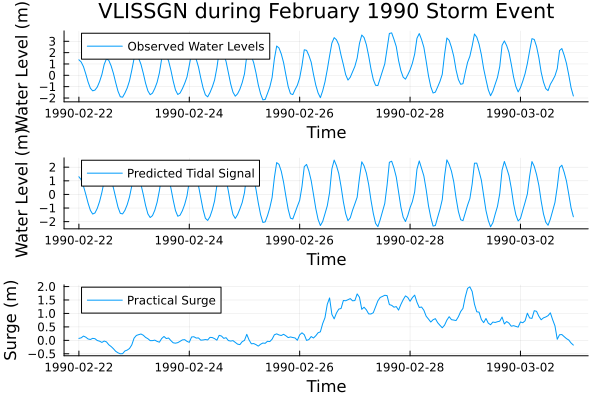

In [24]:
# Select the storm event period for plotting
pred_feb1990 = select_timespan(pred1990, start_time_feb1990, end_time_feb1990)
surge_feb1990 = select_timespan(surge1990, start_time_feb1990, end_time_feb1990)
# Plot the observed water levels, preded tidal signal, and practical surge for the February 1990 storm event
p1=plot(get_times(obs_feb1990), get_values(obs_feb1990)[1,:], label="Observed Water Levels", 
    xlabel="Time", ylabel="Water Level (m)", title="VLISSGN during February 1990 Storm Event", legend=:topleft)
p2=plot(get_times(pred_feb1990), get_values(pred_feb1990)[1,:], label="Predicted Tidal Signal", xlabel="Time", ylabel="Water Level (m)", legend=:topleft)
p3=plot(get_times(surge_feb1990), get_values(surge_feb1990)[1,:], label="Practical Surge", xlabel="Time", ylabel="Surge (m)", legend=:topleft)
plot(p1, p2, p3, layout=(3,1))